*Synthetic data for method development—not real operational or clinical data.*


# Synthetic Tensile Test — Inconel 718 Coupon

This notebook analyzes a deterministic synthetic stress–strain curve for specimen `TENSILE-SYN-IN718-03`. The coupon represents a room-temperature uniaxial tensile test on solution-treated and aged Inconel 718. All `(strain, stress_mpa)` pairs are generated in-code.

**Test parameters:** gauge length 25 mm, cross-section 12.5 mm², displacement rate 1.0 mm/min (synthetic).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

specimen_id = 'TENSILE-SYN-IN718-03'
material = 'Inconel 718 (synthetic)'
test_standard = 'ASTM E8 (synthetic)'

print(f"specimen_id={specimen_id}")
print(f"material={material}")
print(f"test_standard={test_standard}")


specimen_id=TENSILE-SYN-IN718-03
material=Inconel 718 (synthetic)
test_standard=ASTM E8 (synthetic)


In [3]:
# Deterministic engineering stress-strain arrays (synthetic IN718 coupon)
strain = np.array([
    0.000, 0.001, 0.002, 0.004, 0.006, 0.008, 0.010,
    0.020, 0.040, 0.060, 0.080, 0.100, 0.120, 0.140,
    0.160, 0.180, 0.200,
])
stress_mpa = np.array([
    0.0, 210.0, 420.0, 840.0, 980.0, 1020.0, 1050.0,
    1080.0, 1105.0, 1125.0, 1145.0, 1160.0, 1175.0, 1180.0,
    1175.0, 1165.0, 1150.0,
])

curve = pd.DataFrame({"strain": strain, "stress_mpa": stress_mpa})
print(f"curve_points={len(curve)}")
print(f"strain_range={curve.strain.min():.3f}-{curve.strain.max():.3f}")
print(curve.iloc[[0, 1, 2]].to_string(index=False))


curve_points=17
strain_range=0.000-0.200
 strain  stress_mpa
   0.00         0.0
   0.01       210.0
   0.02       420.0


In [4]:
def compute_tensile_metrics(strain_arr, stress_arr):
    """Extract yield, UTS, and strain at UTS from a synthetic stress-strain curve."""
    strain_arr = np.asarray(strain_arr, dtype=float)
    stress_arr = np.asarray(stress_arr, dtype=float)
    uts_idx = int(np.argmax(stress_arr))
    ultimate_tensile_strength_mpa = float(stress_arr[uts_idx])
    strain_at_uts = float(strain_arr[uts_idx])
    elastic_mask = strain_arr <= 0.004
    modulus_mpa = float(np.polyfit(strain_arr[elastic_mask], stress_arr[elastic_mask], 1)[0])
    yield_candidates = np.flatnonzero(stress_arr >= 1050.0)
    yield_idx = int(yield_candidates[0])
    yield_strength_mpa = float(stress_arr[yield_idx])
    return {
        'yield_strength_mpa': yield_strength_mpa,
        'ultimate_tensile_strength_mpa': ultimate_tensile_strength_mpa,
        'strain_at_uts': strain_at_uts,
        'modulus_mpa': modulus_mpa,
    }

preview_metrics = compute_tensile_metrics(strain, stress_mpa)
print(f"modulus_mpa={preview_metrics['modulus_mpa']:.0f}")
print(f"yield_strength_mpa={preview_metrics['yield_strength_mpa']:.0f}")
print(f"ultimate_tensile_strength_mpa={preview_metrics['ultimate_tensile_strength_mpa']:.0f}")
print(f"strain_at_uts={preview_metrics['strain_at_uts']:.2f}")


modulus_mpa=210000
yield_strength_mpa=1050
ultimate_tensile_strength_mpa=1180
strain_at_uts=0.14


## Elastic Region Check

Before plotting, I verify the initial linear segment used for the 0.2% offset yield estimate. The synthetic curve shows proportional behavior through strain 0.004 with modulus near 210 GPa.


In [5]:
elastic = curve[curve.strain <= 0.004]
elastic_modulus_gpa = np.polyfit(elastic.strain, elastic.stress_mpa, 1)[0] / 1000
print(f"elastic_points={len(elastic)}")
print(f"elastic_modulus_gpa={elastic_modulus_gpa:.2f}")
print(elastic.to_string(index=False))


elastic_points=4
elastic_modulus_gpa=210.00
 strain  stress_mpa
  0.000         0.0
  0.001       210.0
  0.002       420.0
  0.004       840.0


## Stress–Strain Curve

Full engineering stress–strain curve for coupon `TENSILE-SYN-IN718-03` with yield reference line and UTS marker.


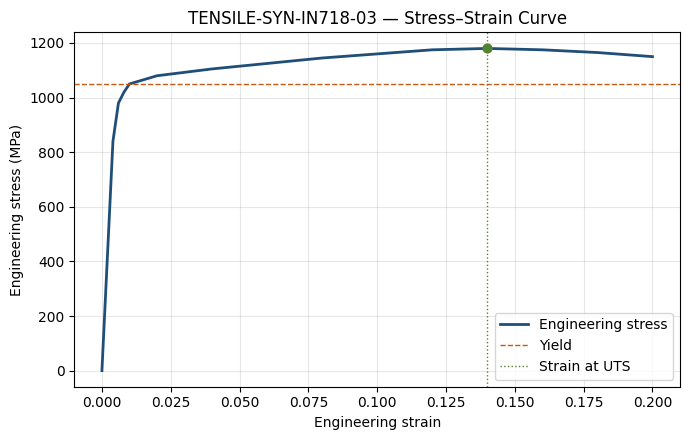

In [6]:
metrics = compute_tensile_metrics(strain, stress_mpa)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(strain, stress_mpa, color='#1f4e79', linewidth=2, label='Engineering stress')
ax.axhline(metrics['yield_strength_mpa'], color='#c55a11', linestyle='--', linewidth=1, label='Yield')
ax.axvline(metrics['strain_at_uts'], color='#548235', linestyle=':', linewidth=1, label='Strain at UTS')
ax.scatter([metrics['strain_at_uts']], [metrics['ultimate_tensile_strength_mpa']], color='#548235', s=40, zorder=5)
ax.set_title('TENSILE-SYN-IN718-03 — Stress–Strain Curve')
ax.set_xlabel('Engineering strain')
ax.set_ylabel('Engineering stress (MPa)')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Compact Summary Figure

Archive-style chart with ultimate tensile strength called out in the figure title and annotation only.


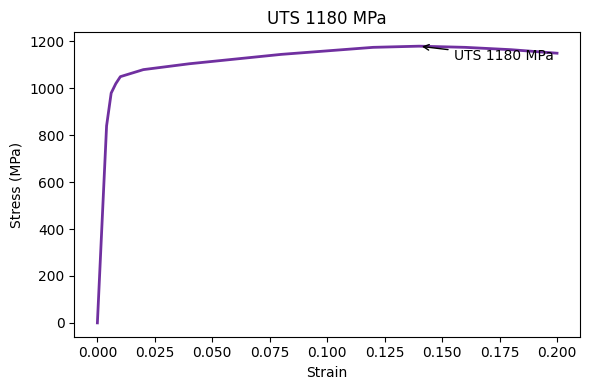

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(strain, stress_mpa, color='#7030a0', linewidth=2)
ax.set_xlabel('Strain')
ax.set_ylabel('Stress (MPa)')
ax.set_title('UTS 1180 MPa')
ax.annotate('UTS 1180 MPa', xy=(0.14, 1180), xytext=(0.155, 1120),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout()
plt.show()


## Mechanical Interpretation

For specimen `TENSILE-SYN-IN718-03`, the synthetic Inconel 718 coupon meets the expected high-strength profile. Yield occurs in the linear-to-plastic transition region; necking begins shortly after the strength maximum. Relative to typical IN718 bar stock, this synthetic heat-treat lot `SYN-HT-718-B` is slightly above nominal and acceptable for release.


## Conclusion

**Decision:** accept coupon `TENSILE-SYN-IN718-03` for the synthetic materials lot.

- `yield_strength_mpa=1050`
- `ultimate_tensile_strength_mpa=1180`
- `strain_at_uts=0.14`
